In [41]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader,TensorDataset
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import torchvision
from torchvision import datasets, transforms
from matplotlib import style
style.use('dark_background')
from torchsummary import summary

In [28]:
transform_train = transforms.Compose([
    transforms.RandomCrop(32,padding = 4),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize((0.5,0.5,0.5),
                         (0.5,0.5,0.5))
])

transform_test = transforms.Compose([
    transforms.RandomCrop(32,padding = 4),
    transforms.ToTensor(),
    transforms.Normalize((0.5,0.5,0.5),
                         (0.5,0.5,0.5))
])

train_data = torchvision.datasets.CIFAR10(root = ',/data',train = True,download = True,transform = transform_train)

test_data = torchvision.datasets.CIFAR10(root = './data',train = False,download = True,transform = transform_test)


Files already downloaded and verified


C:\Users\amsha\PycharmProjects\PythonProject2\.venv\Lib\site-packages\torchvision\datasets\cifar.py:83: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  entry = pickle.load(f, encoding="latin1")


Files already downloaded and verified


In [29]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
device

device(type='cuda')

In [30]:
image,label = train_data[0]
print(image.shape)

torch.Size([3, 32, 32])


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.0..1.0].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.0..0.99215686].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.0..1.0].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.0..0.8352941].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.0..0.99215686].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.0..0.94509804].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.0..0.9529412].
Clipping input data to the valid ran

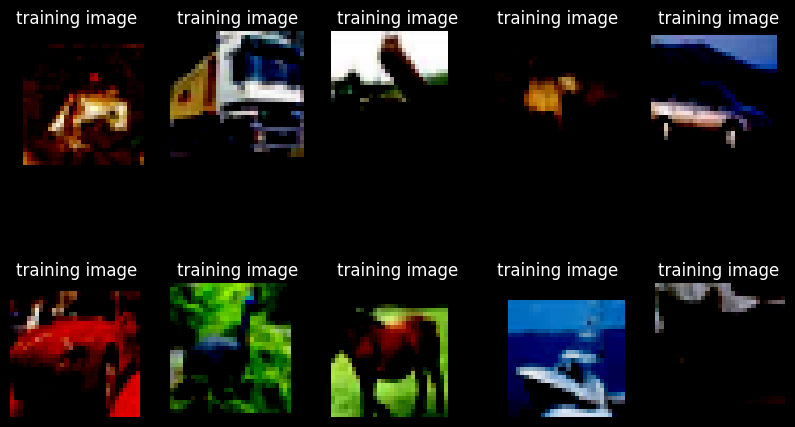

In [31]:
fig,axes = plt.subplots(2,5,figsize = (10,6))
for i,ax in enumerate(axes.flat):
    image,label = train_data[i]
    ax.imshow(image.permute(1,2,0))
    ax.set_title('training image')
    ax.axis('off')

plt.show()

In [32]:
train_loader = DataLoader(train_data,batch_size = 32,shuffle = True)
test_loader = DataLoader(train_data,batch_size = 32)

In [46]:
class NN_Classifier(nn.Module):
    def __init__(self):
        super().__init__()
        self.convo1 = nn.Conv2d(3,32,kernel_size = 3,padding = 1)
        self.bn1 = nn.BatchNorm2d(32)
        self.convo2 =nn.Conv2d(32,64,kernel_size = 3,padding = 1)
        self.bn2 = nn.BatchNorm2d(64)
        self.convo3 = nn.Conv2d(64,128,kernel_size = 3,padding = 1)
        self.bn3 = nn.BatchNorm2d(128)

        self.fc1 = nn.Linear(128*4*4,512)
        self.dropout = nn.Dropout(0.5)
        self.fc2 = nn.Linear(512,10)

    def forward(self,x):
        x = F.relu(self.bn1(self.convo1(x)))
        x = F.max_pool2d(x,2)
        x = F.relu(self.bn2(self.convo2(x)))
        x = F.max_pool2d(x,2)
        x = F.relu(self.bn3(self.convo3(x)))
        x = F.max_pool2d(x,2)
        x = x.view(x.size(0),-1)
        x = F.relu(self.fc1(x))
        x = self.dropout(x)
        x = self.fc2(x)
        return x

In [47]:
model = NN_Classifier()
summary(model,(3,32,32))

Layer (type:depth-idx)                   Output Shape              Param #
├─Conv2d: 1-1                            [-1, 32, 32, 32]          896
├─BatchNorm2d: 1-2                       [-1, 32, 32, 32]          64
├─Conv2d: 1-3                            [-1, 64, 16, 16]          18,496
├─BatchNorm2d: 1-4                       [-1, 64, 16, 16]          128
├─Conv2d: 1-5                            [-1, 128, 8, 8]           73,856
├─BatchNorm2d: 1-6                       [-1, 128, 8, 8]           256
├─Linear: 1-7                            [-1, 512]                 1,049,088
├─Dropout: 1-8                           [-1, 512]                 --
├─Linear: 1-9                            [-1, 10]                  5,130
Total params: 1,147,914
Trainable params: 1,147,914
Non-trainable params: 0
Total mult-adds (M): 11.38
Input size (MB): 0.01
Forward/backward pass size (MB): 0.88
Params size (MB): 4.38
Estimated Total Size (MB): 5.27


Layer (type:depth-idx)                   Output Shape              Param #
├─Conv2d: 1-1                            [-1, 32, 32, 32]          896
├─BatchNorm2d: 1-2                       [-1, 32, 32, 32]          64
├─Conv2d: 1-3                            [-1, 64, 16, 16]          18,496
├─BatchNorm2d: 1-4                       [-1, 64, 16, 16]          128
├─Conv2d: 1-5                            [-1, 128, 8, 8]           73,856
├─BatchNorm2d: 1-6                       [-1, 128, 8, 8]           256
├─Linear: 1-7                            [-1, 512]                 1,049,088
├─Dropout: 1-8                           [-1, 512]                 --
├─Linear: 1-9                            [-1, 10]                  5,130
Total params: 1,147,914
Trainable params: 1,147,914
Non-trainable params: 0
Total mult-adds (M): 11.38
Input size (MB): 0.01
Forward/backward pass size (MB): 0.88
Params size (MB): 4.38
Estimated Total Size (MB): 5.27

In [51]:
epochs = 50
losses = torch.zeros(epochs)
lossfun = nn.CrossEntropyLoss()
trainAcc = []
testAcc = []
optimizer = torch.optim.Adam(model.parameters(),lr = 0.001)
model.to(device)
for epoch in range(epochs):
    batchAcc = []
    batchLoss = []
    for X,y in train_loader:
        model.train()
        X = X.to(device)
        y = y.to(device)
        ypred = model(X)
        loss = lossfun(ypred, y)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        y = y.cpu()
        ypred = ypred.cpu()
        batchLoss.append(loss.item())
        acc = 100*(torch.argmax(ypred,1)==y).float().mean()
        batchAcc.append(acc)

    losses[epoch] = np.mean(batchLoss)
    trainAcc.append(np.mean(batchAcc))

    model.eval()
    X,y = next(iter(test_loader))
    X = X.to(device)
    y = y.to(device)
    with torch.no_grad():
        ypred = model(X)
        ypred = ypred.cpu()
        y = y.cpu()
        acc2 = 100*(torch.argmax(ypred,1)==y).float().mean()
    testAcc.append(acc2)

    if (epoch % 20) == 0:
        print(f'epoch : {epoch},loss {loss}')


epoch : 0,loss 0.7220567464828491
epoch : 20,loss 0.5547663569450378
epoch : 40,loss 0.6257131099700928


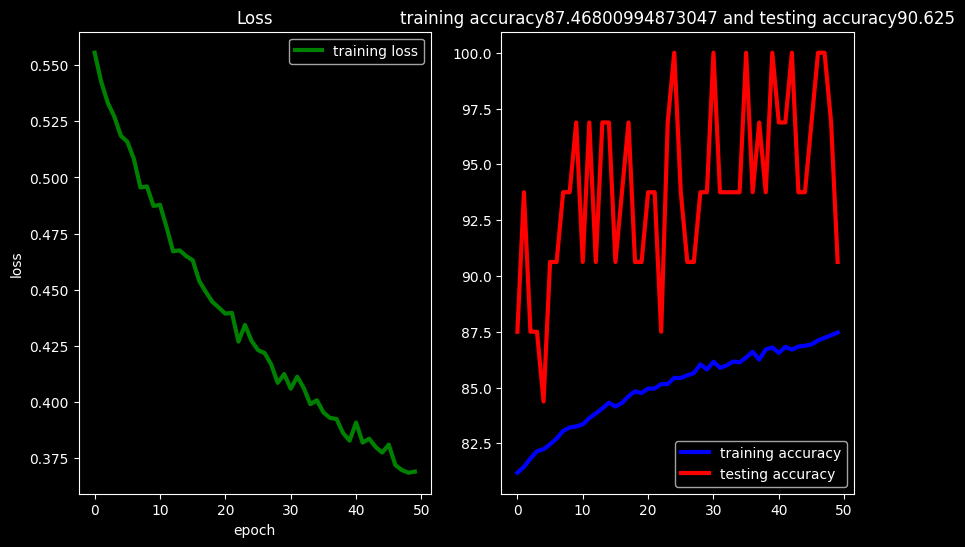

In [55]:
fig,ax = plt.subplots(1,2,figsize = (10,6))
ax[0].plot(losses,'g',lw = 3,label = 'training loss')
ax[0].set_title('Loss')
ax[0].set_xlabel('epoch')
ax[0].set_ylabel('loss')
ax[0].legend()

ax[1].plot(trainAcc,'b',lw = 3,label = 'training accuracy')
ax[1].plot(testAcc,'r',lw = 3,label = 'testing accuracy')
ax[1].set_title(f'training accuracy{trainAcc[-1]} and testing accuracy{testAcc[-1]}')
ax[1].legend()
plt.show()